<a href="https://colab.research.google.com/github/kev841/test-1/blob/main/notebook/diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install Relevant Libraries

In [17]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score


from sklearn.metrics import confusion_matrix as sk_confusion_matrix # Aliased import
from sklearn.metrics import classification_report

# Load Data

In [18]:
# notebook lives in notebook/ so go up one level to find the data folder

data = pd.read_csv('../data/diabetes.csv')  # relative from notebook directory

# show first rows to confirm it loaded correctly
data.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [19]:
data.describe(include='all')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [20]:
data.nsmallest(5, 'Glucose')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,1,0,48,20,0,24.7,0.140,22,0
182,1,0,74,20,23,27.7,0.299,21,0
342,1,0,68,35,0,32.0,0.389,22,0
349,5,0,80,32,0,41.0,0.346,37,1
502,6,0,68,41,0,39.0,0.727,41,1


check for missing data


In [21]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

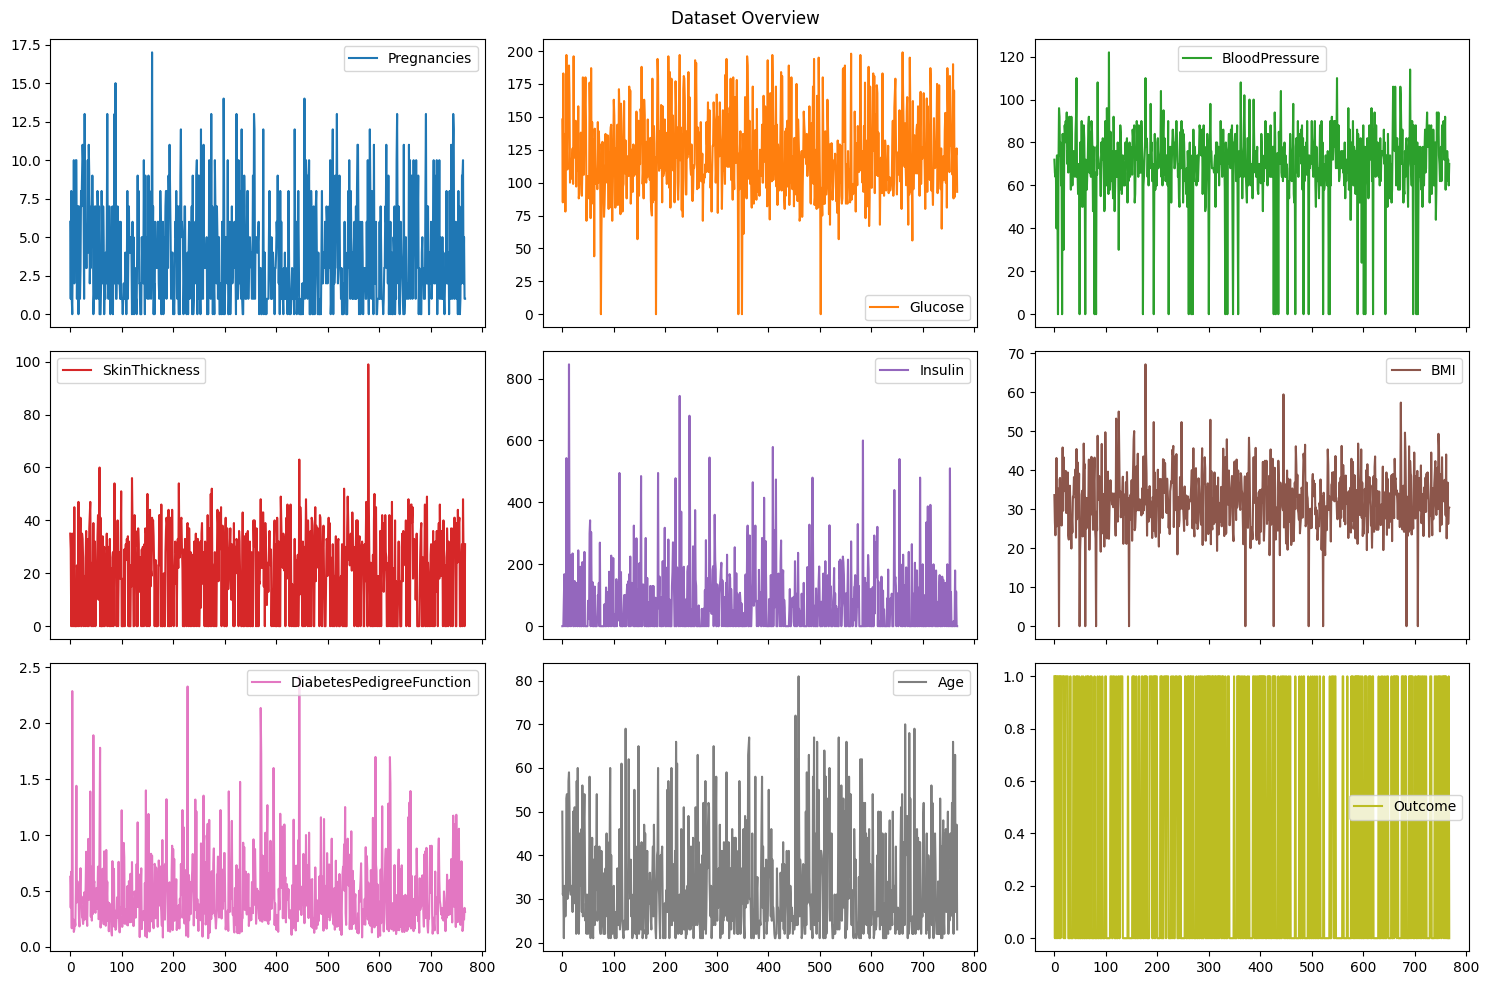

In [22]:
# Plotting every column in its own separate graph
data.plot(subplots=True, layout=(3, 3), figsize=(15, 10), title="Dataset Overview")
plt.tight_layout()
plt.show()


In the dataset there are multiple records of zero entries which need to be handled

In [23]:
zero_cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for c in zero_cols:
  print(c, "zero count:", (data[c]==0).sum())

Glucose zero count: 5
BloodPressure zero count: 35
SkinThickness zero count: 227
Insulin zero count: 374
BMI zero count: 11


hanndilng zeros glucose column

In [24]:
# 1. Replace 0 with NaN so they aren't included in median calculation
data['Glucose'] = data['Glucose'].replace(0, np.nan)

# 2/ Fill NaN values with the median of their respective 'Outcome' group
data['Glucose'] = data['Glucose'].fillna(data.groupby('Outcome')['Glucose'].transform('median'))

# 3. Verify there are no zeros or NaNs left
print("Remaining Zeros:", (data['Glucose'] == 0).sum())
print("Remaining NaNs:", data['Glucose'].isnull().sum())

Remaining Zeros: 0
Remaining NaNs: 0


handling the blood pressure and bmi column

In [25]:
data[['BloodPressure','BMI']] = data[['BloodPressure','BMI']].replace(0, np.nan)

fill with grouped median

In [26]:
data['BloodPressure'] = data['BloodPressure'].fillna(data.groupby('Outcome')['BloodPressure'].transform('median'))
data['BMI'] = data['BMI'].fillna(data.groupby('Outcome')['BMI'].transform('median'))
data[['BloodPressure','BMI']].isnull().sum()

BloodPressure    0
BMI              0
dtype: int64

handled the skin thickness nad insulin columns

In [27]:
data['SkinThickness'] = data['SkinThickness'].replace(0, np.nan)
data['SkinThickness']= data['SkinThickness'].fillna(data.groupby('Outcome')['SkinThickness'].transform('median'))
data['SkinThickness'].isnull().sum()
data['Insulin'] = data['Insulin'].replace(0, np.nan)
data['Insulin']= data['Insulin'].fillna(data.groupby('Outcome')['Insulin'].transform('median'))
data['Insulin'].isnull().sum()

np.int64(0)

In [28]:
data.describe(include='all')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


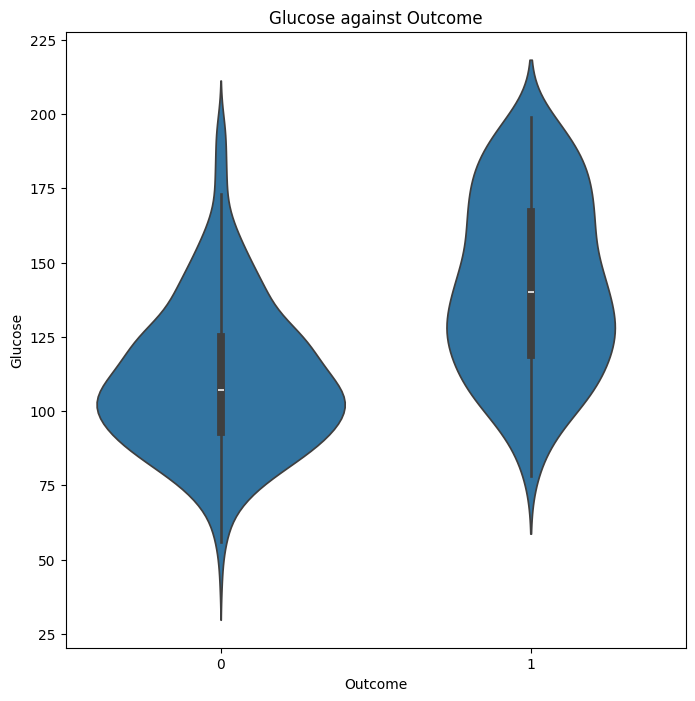

In [29]:
plt.figure(figsize=(8,8))
plt.title("Glucose against Outcome")
sns.violinplot(x=data['Outcome'], y=data['Glucose'], data=data, inner="box")
plt.show()

correlation analysis to identify which factors influence the 'Outcome'

In [30]:
correlation_matrix = data.corr()
print(data.corr()['Outcome'].sort_values(ascending=False))

Outcome                     1.000000
Glucose                     0.495990
Insulin                     0.377081
BMI                         0.315577
SkinThickness               0.295138
Age                         0.238356
Pregnancies                 0.221898
BloodPressure               0.174469
DiabetesPedigreeFunction    0.173844
Name: Outcome, dtype: float64


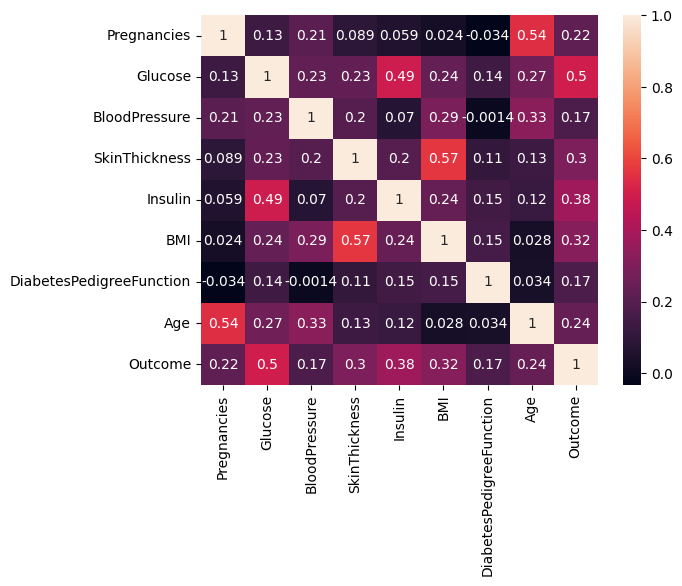

In [31]:
# Visualizing the correlation using a heatmap
sns.heatmap(correlation_matrix, annot=True)
plt.show()

i am going to be using Random Forest to measure how much each variable contributes to predicting the Outcome of a person having diabetes

## Prepare Data

In [32]:
from sklearn.ensemble import RandomForestClassifier

X = data[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']]
y = data['Outcome']

# train model
model = RandomForestClassifier()
model.fit(X,y)

importance = model.feature_importances_
importance

array([0.0506344 , 0.15189701, 0.04735179, 0.14104261, 0.37282607,
       0.08434964, 0.07082629, 0.08107218])

                    Feature  Importance
4                   Insulin    0.372826
1                   Glucose    0.151897
3             SkinThickness    0.141043
5                       BMI    0.084350
7                       Age    0.081072
6  DiabetesPedigreeFunction    0.070826
0               Pregnancies    0.050634
2             BloodPressure    0.047352


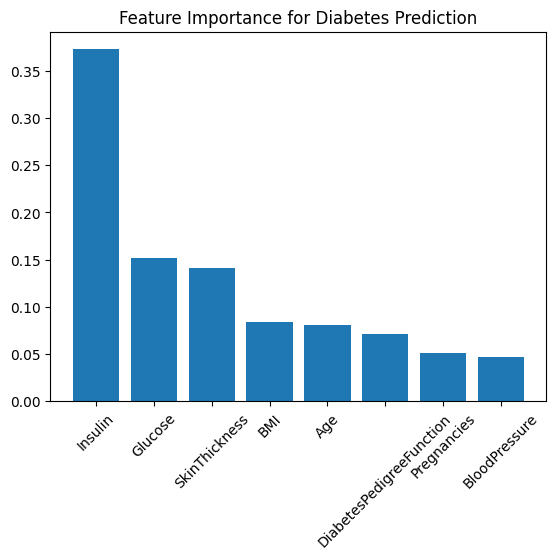

In [33]:
# create a table to show each feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

# Plot
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance for Diabetes Prediction")
plt.show()

# Train model using a Logistic Regression

In [34]:
# Split Data
X = data[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']]
Y = data['Outcome']

In [35]:
#train test and split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

from sklearn.preprocessing import StandardScaler

# 1. Initialize the scaler
scaler = StandardScaler()

# 2. Fit and transform the TRAINING data
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform the TEST data
X_test_scaled = scaler.transform(X_test)

from sklearn.ensemble import RandomForestClassifier

# limit 'max_depth' so the trees don't grow forever and memorize noise
# increase 'min_samples_leaf' so a pattern must apply to at least 5 people to be counted
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,            # Prevents trees from getting too complex
    min_samples_leaf=5,      # Ensures the model finds general patterns, not unique cases
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train_scaled, Y_train)
print(f"New Training Acc: {rf_model.score(X_train_scaled, Y_train):.4f}")
print(f"New Test Acc: {rf_model.score(X_test_scaled, Y_test):.4f}")


# 3. Predict labels (0 or 1)
Y_pred_rf = rf_model.predict(X_test_scaled)

# 4. Predict probabilities (for that sweet AUC)
Y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# 5. Check the new scores
print(f"RF Accuracy: {accuracy_score(Y_test, Y_pred_rf):.4f}")
print(f"RF Recall: {recall_score(Y_test, Y_pred_rf):.4f}")
print(f"RF AUC: {roc_auc_score(Y_test, Y_prob_rf):.4f}")


New Training Acc: 0.9365
New Test Acc: 0.8506
RF Accuracy: 0.8506
RF Recall: 0.8148
RF AUC: 0.9354


# confusion Matrix

In [38]:
# use the predictions from the random forest model (Y_pred_rf)
cm = sk_confusion_matrix(Y_test, Y_pred_rf)
print("Confusion Matrix:", cm)

Confusion Matrix: [[87 13]
 [10 44]]


In [39]:
#classification report for RF predictions
print(classification_report(Y_test, Y_pred_rf))

              precision    recall  f1-score   support

           0       0.90      0.87      0.88       100
           1       0.77      0.81      0.79        54

    accuracy                           0.85       154
   macro avg       0.83      0.84      0.84       154
weighted avg       0.85      0.85      0.85       154



In [41]:
# Check training accuracy
train_acc = rf_model.score(X_train_scaled, Y_train)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {accuracy_score(Y_test, Y_pred_rf):.4f}")


Training Accuracy: 0.9365
Test Accuracy: 0.8506


In [42]:
!jupyter nbconvert --clear-output --inplace /content/diabetes.ipynb

usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: kernel kernelspec migrate run troubleshoot

Jupyter command `jupyter-nbconvert` not found.


In [44]:
import pickle
pickle.dump(model, open("diabetes.pkl", "wb"))